# 010.a — Benchmark: EinsteinPy vs RelatiPy

Comparación de **tiempo de pared** para integrar una geodésica temporal en **Kerr**
(spin `a = 0.9`), variando el número de pasos. Se mide con repeticiones (`timeit`)
reportando el mínimo (menos ruido del scheduler) y la media.

- **RelatiPy**: `Kerr(a=0.9).geodesic.get_path` con integrador `Radau2` (`adaptative=False`),
  especializado para Kerr en Boyer-Lindquist.
- **EinsteinPy**: `einsteinpy.geodesic.Timelike(metric="Kerr")` (integrador simpléctico
  en espacio de fases).

Ambos producen una trayectoria de `N` puntos en la misma geometría Kerr.
Los algoritmos difieren (Radau2 implícito vs. simpléctico), así que esto compara
**costo de producir una órbita**, no exactitud punto a punto.


In [1]:
import time
import numpy as np
import pandas as pd
import astropy.units as u

from relatipy.numeric.metrics import Kerr
from relatipy.numeric.coordinates import OrbitalElements
from einsteinpy.geodesic import Timelike

# --- Configuración física común (misma órbita nominal) ---
M = 1.989e30 * u.kg          # masa central (~1 M_sun)
SPIN = 0.9                   # spin adimensional a/M (Kerr, sub-extremal)
STEP_COUNTS = [500, 1000, 2000, 4000]
REPEATS = 5                  # repeticiones por punto para timing robusto

# Órbita: r0 ~ 40 M, ligeramente excéntrica
R0 = 40.0                    # radio inicial (unidades geométricas, r/M)
L  = 3.83                    # momento angular específico (elegido para órbita ligada)
TAU_MAX = 200.0              # rango de tiempo propio para RelatiPy
DELTA = 0.5                  # paso afín para EinsteinPy


In [2]:
def run_relatipy(n_steps):
    """Integra una geodésica con RelatiPy (Kerr a=SPIN, Radau2). Devuelve nº de puntos."""
    metric = Kerr(M, a=SPIN)
    ic = OrbitalElements(a=R0, e=0.2, mass=M)
    taus = np.linspace(0.0, TAU_MAX, n_steps)
    path = metric.geodesic.get_path(ic, taus, integrator="Radau2", adaptative=False)
    xs = np.asarray(path.xs)               # shape (4, N) en Boyer-Lindquist
    return xs.shape[-1]


def run_einsteinpy(n_steps):
    """Integra una geodésica con EinsteinPy (Kerr a=SPIN). Devuelve nº de puntos."""
    geod = Timelike(
        metric="Kerr",
        metric_params=(SPIN,),
        position=[R0, np.pi / 2, 0.0],
        momentum=[0.0, 0.0, L],
        steps=n_steps,
        delta=DELTA,
        return_cartesian=True,
    )
    return np.asarray(geod.trajectory[1]).shape[0]


def bench(fn, n_steps, repeats=REPEATS):
    """Corre fn(n_steps) `repeats` veces. Devuelve (min, mean) en segundos."""
    fn(n_steps)  # warm-up (JIT/imports/cachés)
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(n_steps)
        ts.append(time.perf_counter() - t0)
    ts = np.array(ts)
    return ts.min(), ts.mean()


In [3]:
rows = []
for n in STEP_COUNTS:
    r_min, r_mean = bench(run_relatipy, n)
    e_min, e_mean = bench(run_einsteinpy, n)
    rows.append({
        "n_steps": n,
        "relatipy_min_s": r_min,
        "relatipy_mean_s": r_mean,
        "einsteinpy_min_s": e_min,
        "einsteinpy_mean_s": e_mean,
        "speedup_x": e_min / r_min,   # cuántas veces más rápido es RelatiPy
    })

df = pd.DataFrame(rows).set_index("n_steps")
df


,relatipy_min_s,relatipy_mean_s,einsteinpy_min_s,einsteinpy_mean_s,speedup_x
n_steps,,,,,
500,0.001047,0.001153,2.009615,2.081654,1919.403335
1000,0.001082,0.001291,4.059844,4.104296,3750.578928
2000,0.001180,0.001277,8.145963,8.151375,6905.799128
4000,0.001369,0.001403,15.971488,16.114766,11664.406125


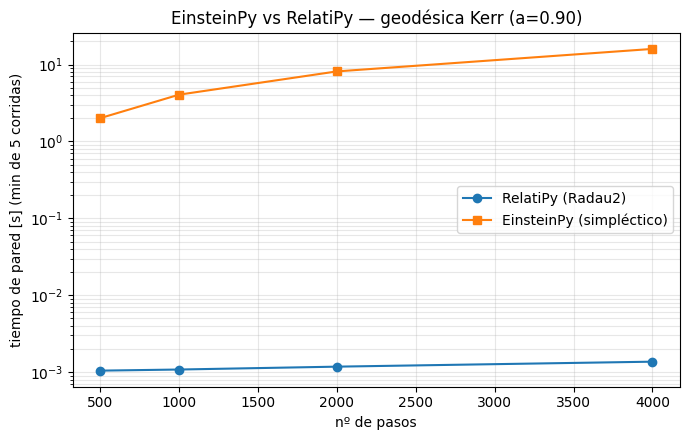

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df.index, df["relatipy_min_s"],   "o-", label="RelatiPy (Radau2)")
ax.plot(df.index, df["einsteinpy_min_s"], "s-", label="EinsteinPy (simpléctico)")
ax.set_xlabel("nº de pasos")
ax.set_ylabel("tiempo de pared [s] (min de %d corridas)" % REPEATS)
ax.set_yscale("log")
ax.set_title("EinsteinPy vs RelatiPy — geodésica Kerr (a=%.2f)" % SPIN)
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()
